In [86]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [87]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [88]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanop

In [89]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'
# quantum_band = r'kp8'
# quantum_band_interactions = r'kp8_kp8'

C:\Users\sp6497_a\nextnanopy_projects\nextnano_tools\simstructs.py:584: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6))


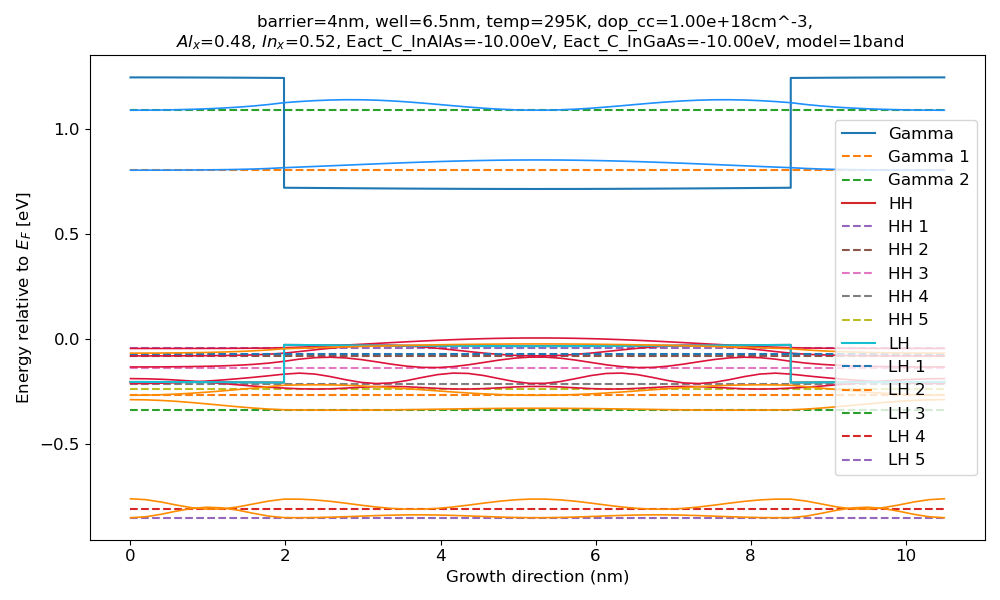

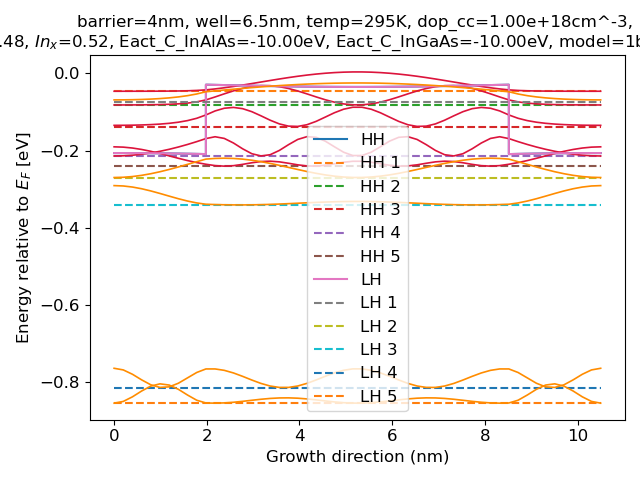

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'barrier=4nm, well=6.5nm, temp=295K, dop_cc=1.00e+18cm^-3, \n $Al_x$=0.48, $In_x$=0.52, Eact_C_InAlAs=-10.00eV, Eact_C_InGaAs=-10.00eV, model=1band HH and LH'}, xlabel='Growth direction (nm)', ylabel='Energy relative to $E_F$ [eV]'>)

In [90]:
%matplotlib widget
parent_dir = r'C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\InGaAs_InAlAs_SW_singleband_or_kp8(2)'
model = '1band'
simoutidk = build_output(parent_dir, quantum_region, bias, 14, model=model)

# simoutidk = build_output(parent_dir, quantum_region, bias, 14, model=model,VB_cutoff=0.25,quantum_band=quantum_band, quantum_band_interactions=quantum_band_interactions)
# simoutidk.bands['CB'].sort_subbands(decreasing=False)
# simoutidk.bands['VB'].sort_subbands(decreasing=True)
simoutidk.bands['Gamma'].sort_subbands(decreasing=False)
simoutidk.bands['HH'].sort_subbands(decreasing=True)
simoutidk.bands['LH'].sort_subbands(decreasing=True)

barrier_len = simoutidk.variables['w_barrier']
well_len = simoutidk.variables['w_well']
temp = simoutidk.variables['temp']

dop_cc = simoutidk.variables['impurity_conc_cc']
# Al_x = simoutidk.variables['Al_alloy']
Al_alloy = simoutidk.variables['Al_alloy']
In_alloy = simoutidk.variables['In_alloy']
Eact_C_InAlAs = simoutidk.variables['Eact_C_InAlAs']
Eact_C_InGaAs = simoutidk.variables['Eact_C_InGaAs']

title_base = f"barrier={barrier_len}nm, well={well_len}nm, temp={temp}K, dop_cc={dop_cc:.2e}cm^-3, \n $Al_x$={Al_alloy:.2f}, $In_x$={In_alloy:.2f}, Eact_C_InAlAs={Eact_C_InAlAs:.2f}eV, Eact_C_InGaAs={Eact_C_InGaAs:.2f}eV, model={model}"
# all_band_fig,all_band_ax = plt.subplots()
simoutidk.plot_all_bands(title_diff=title_base,fontsizebase=12,fontsizetitle=12)

VB_fig,VB_ax = plt.subplots()
# simoutidk.bands['VB'].plot_band(ax=VB_ax,title_diff=title_base+' VB only', normalize_y=False,show=True,fontsizetitle=12,fontsizebase=12)
simoutidk.bands['HH'].plot_band(ax=VB_ax,title_diff=title_base+' HH only', normalize_y=False,show=False,fontsizetitle=12,fontsizebase=12)

simoutidk.bands['LH'].plot_band(ax=VB_ax,title_diff=title_base+' HH and LH', normalize_y=False,show=True,fontsizetitle=12,fontsizebase=12)


In [91]:
simoutidk.bands

{'Gamma': <BandStructure name=Gamma, 2 subbands: [0.8027 eV, 1.0900 eV]>,
 'HH': <BandStructure name=HH, 5 subbands: [-0.0463 eV, -0.0818 eV, -0.1377 eV, -0.2138 eV, -0.2401 eV]>,
 'LH': <BandStructure name=LH, 5 subbands: [-0.0748 eV, -0.2696 eV, -0.3405 eV, -0.8132 eV, -0.8535 eV]>}